In [6]:
import numpy as np
import pandas as pd
movies = pd.read_csv('movies.csv')
ipl = pd.read_csv('ipl-matches.csv')
students = pd.DataFrame(
    {
        'name':['nitish','ankit','rupesh',np.nan,'mrityunjay',np.nan,'rishabh',np.nan,'aditya',np.nan],
        'college':['bit','iit','vit',np.nan,np.nan,'vlsi','ssit',np.nan,np.nan,'git'],
        'branch':['eee','it','cse',np.nan,'me','ce','civ','cse','bio',np.nan],
        'cgpa':[6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
        'package':[4,5,6,np.nan,6,7,8,9,np.nan,np.nan]

    }
)
batsman = pd.read_csv('batsman_runs_ipl.csv')
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}
marks_series = pd.Series(marks)

Important DataFrame Functions

1. astype --> Change the data type of given column

In [3]:
print(ipl.info())
ipl['ID'] = ipl['ID'].astype('int32')
print(ipl.info())

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

2. value_count (Series and DataFrame) --> Repeated rows/ Row frequency count

When the index value of two series are same then you can add it when you want

    iq  marks  package
0  100     80       10
1   90     70        7
2  120    100       14
3   80     70       14
4   80     70       14
iq   marks  package
80   70     14         2
100  80     10         1
90   70     7          1
120  100    14         1
Name: count, dtype: int64
Player_of_Match
F du Plessis         3
KA Pollard           3
SK Raina             3
JJ Bumrah            2
SR Watson            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
YK Pathan            2
A Kumble             2
HH Pandya            1
JC Buttler           1
RM Patidar           1
DA Miller            1
VR Iyer              1
SP Narine            1
RD Gaikwad           1
TA Boult             1
MP Stoinis           1
KS Williamson        1
RR Pant              1
SA Yadav             1
Rashid Khan          1
AD Russell           1
KH Pandya            1
KV Sharma            1
NM Coulter-Nile      1
Washington Sundar    1
BCJ Cutting          1
DA Warner            1
MC Henriqu

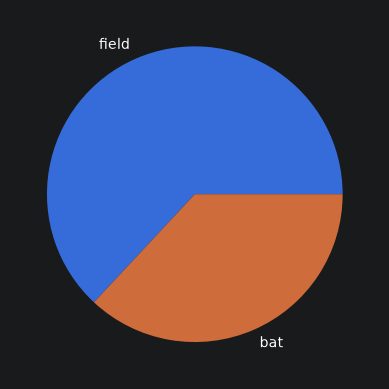

In [7]:
marks = pd.DataFrame([
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,70,14],
    [80,70,14]
],columns=['iq','marks','package'])
print(marks)
print(marks.value_counts())

#Question 1. find which player has won most potm -> in finals and qualifiers
print(ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts())

#Question 2. Toss decision plot
print(ipl['TossDecision'].value_counts().plot(kind='pie'))

#Question 3. how many matches each team has played
print((ipl['Team2'].value_counts() + ipl['Team1'].value_counts()).sort_values(ascending=False))

3. sort_values(series and dataframe) ->

Ascending -> na_position -> inplace -> multiple cols

na_position means position of nan/missing values and inplace is for permanent changes.

In [7]:
print(movies.sort_values('title_x'))  # Ascending Order
print(movies.sort_values('title_x',ascending=False))  # Descending Order
print(students.sort_values('name',na_position='first',ascending=False))
print(movies.sort_values(['year_of_release','title_x'],ascending=[True,False]))  # True for year of release and false for title x

                       title_x    imdb_id  \
1498        16 December (film)  tt0313844   
1021               1920 (film)  tt1301698   
287               1920: London  tt5638500   
723     1920: The Evil Returns  tt2222550   
1039          1971 (2007 film)  tt0983990   
...                        ...        ...   
778   Zindagi Na Milegi Dobara  tt1562872   
670          Zindagi Tere Naam  tt2164702   
756                   Zokkomon  tt1605790   
939      Zor Lagaa Ke...Haiya!  tt1479857   
1623                  Zubeidaa  tt0255713   

                                            poster_path  \
1498  https://upload.wikimedia.org/wikipedia/en/thum...   
1021  https://upload.wikimedia.org/wikipedia/en/thum...   
287   https://upload.wikimedia.org/wikipedia/en/thum...   
723   https://upload.wikimedia.org/wikipedia/en/e/e7...   
1039  https://upload.wikimedia.org/wikipedia/en/thum...   
...                                                 ...   
778   https://upload.wikimedia.org/wikipedia/e

4. rank (series) --> it is used to find rank of any column elements

In [10]:
batsman['batting_rank'] = batsman['batsman_run'].rank(ascending=False)
print(batsman.sort_values('batting_rank'))

             batter  batsman_run  batting_rank
569         V Kohli         6634           1.0
462        S Dhawan         6244           2.0
130       DA Warner         5883           3.0
430       RG Sharma         5881           4.0
493        SK Raina         5536           5.0
..              ...          ...           ...
570  V Pratap Singh            0         594.0
63     Abdur Razzak            0         594.0
562          U Kaul            0         594.0
65       Akash Deep            0         594.0
57           AS Roy            0         594.0

[605 rows x 3 columns]


5. sort_index(series and dataframe) --> It is used to sort index

In [9]:
print(marks_series.sort_index())   # in ascending order on series
print(marks_series.sort_index(ascending=False))  # in descending order on series
print(movies.sort_index(ascending=False))  # Descending order on dataframe
print(batsman.set_index('batter',inplace=True))  # set index of DataFrame

english     57
hindi      100
maths       67
science     89
dtype: int64
science     89
maths       67
hindi      100
english     57
dtype: int64
                               imdb  \
title_x                               
Zubeidaa                  tt0255713   
Zor Lagaa Ke...Haiya!     tt1479857   
Zokkomon                  tt1605790   
Zindagi Tere Naam         tt2164702   
Zindagi Na Milegi Dobara  tt1562872   
...                             ...   
1971 (2007 film)          tt0983990   
1920: The Evil Returns    tt2222550   
1920: London              tt5638500   
1920 (film)               tt1301698   
16 December (film)        tt0313844   

                                                                       link  \
title_x                                                                       
Zubeidaa                  https://upload.wikimedia.org/wikipedia/en/thum...   
Zor Lagaa Ke...Haiya!     https://upload.wikimedia.org/wikipedia/en/thum...   
Zokkomon                  http

6. reset_index (Series + DataFrame) --> Drop parameters and opposite of set_index

In [7]:
print(batsman.reset_index())

#Question 1. series to dataframe using reset_index
print(marks_series.reset_index())

     index          batter  batsman_run
0        0  A Ashish Reddy          280
1        1        A Badoni          161
2        2      A Chandila            4
3        3        A Chopra           53
4        4     A Choudhary           25
..     ...             ...          ...
600    600      Yash Dayal            0
601    601   Yashpal Singh           47
602    602     Younis Khan            3
603    603    Yuvraj Singh         2754
604    604          Z Khan          117

[605 rows x 3 columns]
     index    0
0    maths   67
1  english   57
2  science   89
3    hindi  100


7. rename(dataframe) -> index

In [8]:
print(movies.set_index('title_x',inplace=True))
print(movies.rename(columns={'imdb_id':'imdb','poster_path':'link'},inplace=True))
print(movies.rename(index={'Uri: The Surgical Strike':'Uri','Battalion 609':'Battalion'}))  # To Change index name not it's column

None
None
                                            imdb  \
title_x                                            
Uri                                    tt8291224   
Battalion                              tt9472208   
The Accidental Prime Minister (film)   tt6986710   
Why Cheat India                        tt8108208   
Evening Shadows                        tt6028796   
...                                          ...   
Tera Mera Saath Rahen                  tt0301250   
Yeh Zindagi Ka Safar                   tt0298607   
Sabse Bada Sukh                        tt0069204   
Daaka                                 tt10833860   
Humsafar                               tt2403201   

                                                                                   link  \
title_x                                                                                   
Uri                                   https://upload.wikimedia.org/wikipedia/en/thum...   
Battalion                               

8. unique(series) --> This is extract unique values from series and it is also count missing values.

In [14]:
temp = pd.Series([1,1,2,2,3,3,4,4,5,5,np.nan,np.nan])
print(temp)
print(temp.unique())
print(len(temp.unique()))   # To Count unique values
print(ipl['Season'].unique())
print(len(ipl['Season'].unique()))

0     1.0
1     1.0
2     2.0
3     2.0
4     3.0
5     3.0
6     4.0
7     4.0
8     5.0
9     5.0
10    NaN
11    NaN
dtype: float64
[ 1.  2.  3.  4.  5. nan]
6
<StringArray>
[   '2022',    '2021', '2020/21',    '2019',    '2018',    '2017',    '2016',
    '2015',    '2014',    '2013',    '2012',    '2011', '2009/10',    '2009',
 '2007/08']
Length: 15, dtype: str
15


9. nunique(series + dataframe) -> it's does not count missing values/nan and it is also used to count unique values.

In [15]:
print(ipl['Season'].nunique())  # To count unique values

15


10. isnull(series + dataframe) --> It's use to check missing value is present or not and it's check each value

In [18]:
print(students['name'][students['name'].isnull()])
print(students.isnull())

3    NaN
5    NaN
7    NaN
9    NaN
Name: name, dtype: str
    name  college  branch   cgpa  package
0  False    False   False  False    False
1  False    False   False  False    False
2  False    False   False  False    False
3   True     True    True   True     True
4  False     True   False  False    False
5   True    False   False  False    False
6  False    False   False  False    False
7   True     True   False  False    False
8  False     True   False  False     True
9   True    False    True   True     True


11. notnull(series + dataframe) --> opposite of isnull

it's check each values

missing value --> False and not missing values --> True

In [20]:
print(students['name'][students['name'].notnull()])
print(students.notnull())

0        nitish
1         ankit
2        rupesh
4    mrityunjay
6       rishabh
8        aditya
Name: name, dtype: str
    name  college  branch   cgpa  package
0   True     True    True   True     True
1   True     True    True   True     True
2   True     True    True   True     True
3  False    False   False  False    False
4   True    False    True   True     True
5  False     True    True   True     True
6   True     True    True   True     True
7  False    False    True   True     True
8   True    False    True   True    False
9  False     True   False  False    False


12. hasnans(series) --> It's Check missing value of complete series or dataframe

In [21]:
print(students['name'].hasnans)

True


13. dropna(series + dataframe) -> how parameter -> works like 'or'

In [22]:
#1. To Remove missing values
print(students.dropna())  # This remove all rows where at least one missing value.

#2. We remove only those rows where all columns how missing values
print(students.dropna(how='all'))

#3. We can remove missing values also from particular column or rows
print(students.dropna(subset=['name']))
print(students.dropna(subset=['name','college']))  # works like or

      name college branch  cgpa  package
0   nitish     bit    eee  6.66      4.0
1    ankit     iit     it  8.25      5.0
2   rupesh     vit    cse  6.41      6.0
6  rishabh    ssit    civ  7.40      8.0
         name college branch   cgpa  package
0      nitish     bit    eee   6.66      4.0
1       ankit     iit     it   8.25      5.0
2      rupesh     vit    cse   6.41      6.0
4  mrityunjay     NaN     me   5.60      6.0
5         NaN    vlsi     ce   9.00      7.0
6     rishabh    ssit    civ   7.40      8.0
7         NaN     NaN    cse  10.00      9.0
8      aditya     NaN    bio   7.40      NaN
9         NaN     git    NaN    NaN      NaN
         name college branch  cgpa  package
0      nitish     bit    eee  6.66      4.0
1       ankit     iit     it  8.25      5.0
2      rupesh     vit    cse  6.41      6.0
4  mrityunjay     NaN     me  5.60      6.0
6     rishabh    ssit    civ  7.40      8.0
8      aditya     NaN    bio  7.40      NaN
      name college branch  cgpa  pack

14. fillna(series + dataframe) --> To fill missing values and it is also used column by column.

In [24]:
print(students['name'].fillna('unknown'))  # Series
print(students.fillna(0))  # DataFrame

# it is also used column by column
print(students['package'].fillna(students['package'].mean()))

0        nitish
1         ankit
2        rupesh
3       unknown
4    mrityunjay
5       unknown
6       rishabh
7       unknown
8        aditya
9       unknown
Name: name, dtype: str
         name college branch   cgpa  package
0      nitish     bit    eee   6.66      4.0
1       ankit     iit     it   8.25      5.0
2      rupesh     vit    cse   6.41      6.0
3           0       0      0   0.00      0.0
4  mrityunjay       0     me   5.60      6.0
5           0    vlsi     ce   9.00      7.0
6     rishabh    ssit    civ   7.40      8.0
7           0       0    cse  10.00      9.0
8      aditya       0    bio   7.40      0.0
9           0     git      0   0.00      0.0
0    4.000000
1    5.000000
2    6.000000
3    6.428571
4    6.000000
5    7.000000
6    8.000000
7    9.000000
8    6.428571
9    6.428571
Name: package, dtype: float64


15. drop_duplicates(series + dataframe) -> works like and -> duplicated()

In [28]:
# Help to remove duplicates rows
print(marks_series.drop_duplicates())
print(marks_series.drop_duplicates(keep='last'))   # keep='last' is occurance

#Question find the last match played by virat kohli in Delhi
ipl['all_players'] = ipl['Team1Players'] + ipl['Team2Players']
ipl.head()
def did_kohli_play(players_list):
  return 'V Kohli' in players_list
ipl['did_kohli_play'] = ipl['all_players'].apply(did_kohli_play)
print(ipl[(ipl['City'] == 'Delhi') & (ipl['did_kohli_play'] == True)].drop_duplicates(subset=['City','did_kohli_play'],keep='first'))

maths       67
english     57
science     89
hindi      100
dtype: int64
maths       67
english     57
science     89
hindi      100
dtype: int64
          ID   City        Date Season MatchNumber           Team1  \
208  1178421  Delhi  2019-04-28   2019          46  Delhi Capitals   

                           Team2                 Venue      TossWinner  \
208  Royal Challengers Bangalore  Arun Jaitley Stadium  Delhi Capitals   

    TossDecision  ... WonBy Margin method  Player_of_Match  \
208          bat  ...  Runs   16.0    NaN         S Dhawan   

                                          Team1Players  \
208  ['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...   

                                          Team2Players       Umpire1  \
208  ['PA Patel', 'V Kohli', 'AB de Villiers', 'S D...  BNJ Oxenford   

                   Umpire2                                        all_players  \
208  KN Ananthapadmanabhan  ['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...   

    did_kohli_

16. drop(series + dataframe) --> It's used to delete/drop rows and column

In [30]:
#1. Drop Columns
print(students.drop(columns=['branch','cgpa']))

#2. Drop Rows
print(students.drop(index = [0,8]))
print(students.set_index('name').drop(index=['nitish','aditya']))  # both same [0,8]

         name college  package
0      nitish     bit      4.0
1       ankit     iit      5.0
2      rupesh     vit      6.0
3         NaN     NaN      NaN
4  mrityunjay     NaN      6.0
5         NaN    vlsi      7.0
6     rishabh    ssit      8.0
7         NaN     NaN      9.0
8      aditya     NaN      NaN
9         NaN     git      NaN
         name college branch   cgpa  package
1       ankit     iit     it   8.25      5.0
2      rupesh     vit    cse   6.41      6.0
3         NaN     NaN    NaN    NaN      NaN
4  mrityunjay     NaN     me   5.60      6.0
5         NaN    vlsi     ce   9.00      7.0
6     rishabh    ssit    civ   7.40      8.0
7         NaN     NaN    cse  10.00      9.0
9         NaN     git    NaN    NaN      NaN
           college branch   cgpa  package
name                                     
ankit          iit     it   8.25      5.0
rupesh         vit    cse   6.41      6.0
NaN            NaN    NaN    NaN      NaN
mrityunjay     NaN     me   5.60      6.0
Na

17. apply(series + dataframe) --> Series = Columnwise Traverse and DataFrame = Rowise Traverse

In [33]:
#1.
temp = pd.Series([10,20,30,40,50])
def sigmoid(value):
  return 1/1+np.exp(-value)
print(temp.apply(sigmoid))

#2.
points_df = pd.DataFrame(
    {
        '1st point':[(3,4),(-6,5),(0,0),(-10,1),(4,5)],
        '2nd point':[(-3,4),(0,0),(2,2),(10,10),(1,1)]
    }
)
def euclidean(row):
  pt_A = row['1st point']
  pt_B = row['2nd point']
  return ((pt_A[0] - pt_B[0])**2 + (pt_A[1] - pt_B[1])**2)**0.5
points_df['distance'] = points_df.apply(euclidean,axis=1)
print(points_df)

0    1.000045
1    1.000000
2    1.000000
3    1.000000
4    1.000000
dtype: float64
  1st point 2nd point   distance
0    (3, 4)   (-3, 4)   6.000000
1   (-6, 5)    (0, 0)   7.810250
2    (0, 0)    (2, 2)   2.828427
3  (-10, 1)  (10, 10)  21.931712
4    (4, 5)    (1, 1)   5.000000
